In [1]:
## Imporst:

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

In [2]:
# Some general settings

# Enable LaTeX rendering in Matplotlib for text and labels
plt.rc('text', usetex=True)
plt.rc('font', family='serif')


sns.set_theme(style="whitegrid")
sns.set(style="ticks", context="paper", font_scale=0.9)  # Smaller font scale for paper

# Create the plot with refined settings
custom_palette = ['#785EF0',  '#FE6100', '#FFB000', '#DC267F',]
# custom_palette = "tab10"

## 1st kind of plot:

Read/Write for both sequential and parallel IO

In [3]:
df = pd.DataFrame()
for core in [8,16,24,32]:
    for ram in [32,64,128,192]:
        for mode in ["read","write","randwrite","randread"]:
            for replica in [1,2,3]:
                for run_id in [1,2,3,4,5,7]:
                    if ram==128 and core==8 and run_id>3:
                        continue
                    with open(f'multi-node/10-nodes/{mode}_replica_{replica}_core_{core}_memory_{ram}_run_{run_id}.json', 'r') as file:
                        try:
                            job = json.load(file)
                        except:
                            print(f'Error opening: results/{mode}_replica_{replica}_core_{core}_memory_{ram}_run_{run_id}.json')
                            continue
                        job=job["client_stats"]
                        #df= pd.concat([df, df_tmp], ignore_index=True)
                        if "write" in mode:
                            bw=job[7]["write"]["bw_bytes"]/1024/1024/1024
                        else:
                            bw=job[7]["read"]["bw_bytes"]/1024/1024/1024
                        bw_aggregated=0
                        for i in range(0,7):
                            if "write" in mode:
                                bw_aggregated+=job[i]["write"]["bw_bytes"]/1024/1024/1024
                            else:
                                bw_aggregated+=job[i]["read"]["bw_bytes"]/1024/1024/1024                      
                        d={"core":core,"ram":ram,"mode":mode,"replica":replica,"run_id":run_id, "bw":bw,"bw_aggregated":bw_aggregated}
                        experiment=pd.DataFrame(d, index=[0])
                        #print(experiment['jobname'])
                        df= pd.concat([df, experiment], ignore_index=True)
                        #open file
                        # extract bw from job 5
                        # extract sum from 0..5
                        # create a datagrame 

# # df.to_csv('raw_readwrite_randseq.csv', index=False)
# # df = pd.read_csv('raw_readwrite_randseq.csv')

In [4]:
df

,core,ram,mode,replica,run_id,bw,bw_aggregated
0,8,32,read,1,1,2.590910,2.619201
1,8,32,read,1,2,4.793708,4.803063
2,8,32,read,1,3,3.112352,3.130348
3,8,32,read,1,4,3.428578,3.444814
4,8,32,read,1,5,3.779640,3.802585
...,...,...,...,...,...,...,...
1111,32,192,randread,3,2,0.076392,0.076435
1112,32,192,randread,3,3,0.079364,0.079382
1113,32,192,randread,3,4,0.079749,0.079774
1114,32,192,randread,3,5,0.079318,0.079337


In [5]:
# Normalize input w.r.t RAM and CORE
data_tmp = df.copy()
data_tmp["ram"] = data_tmp["ram"] / 14
data_tmp["core"] = data_tmp["core"] / 14

# Normalization w.r.t. the best case (max RAM value)
normalized_data = data_tmp.copy()
normalized_data = normalized_data.drop(columns=["bw_aggregated"])

To better plot everything, costrunct an aggregate dataset

In [6]:
agg_values = normalized_data.groupby(["mode", "core", "ram", "replica"] ).agg(['mean', 'std']).reset_index()
agg_values.columns = ['_'.join(col).strip('_') for col in agg_values.columns.values]
# drop useless column:
agg_values = agg_values.drop(columns=['run_id_mean', 'run_id_std'])
print(agg_values)

         mode      core        ram  replica    bw_mean    bw_std
0    randread  0.571429   2.285714        1   0.053008  0.008285
1    randread  0.571429   2.285714        2   0.051564  0.004382
2    randread  0.571429   2.285714        3   0.046231  0.002089
3    randread  0.571429   4.571429        1   0.045948  0.004081
4    randread  0.571429   4.571429        2   0.050193  0.005661
..        ...       ...        ...      ...        ...       ...
187     write  2.285714   9.142857        2   8.546743  0.396721
188     write  2.285714   9.142857        3   5.702252  0.231024
189     write  2.285714  13.714286        1  15.550222  0.427169
190     write  2.285714  13.714286        2   8.377234  0.665662
191     write  2.285714  13.714286        3   5.700464  0.475368

[192 rows x 6 columns]


In [7]:
normalized_aggregated = agg_values.copy()
normalized_aggregated["bw_norm"] = normalized_aggregated["bw_mean"]
normalized_aggregated["bw_std_norm"] = normalized_aggregated["bw_std"]

# Define reference values
ref_core = 32 / 14
ref_ram = 192 / 14

normalization_constants = {}
for mode in ["read", "write", "randread", "randwrite"]:
    df_mode = normalized_aggregated[
        (np.isclose(normalized_aggregated["core"], ref_core)) &
        (np.isclose(normalized_aggregated["ram"], ref_ram)) &
        (normalized_aggregated["mode"] == mode)
    ]
    normalization_constants[mode] = df_mode.set_index("replica")

# Normalize bandwidth and std deviation
for i in range(len(normalized_aggregated)):
    row = normalized_aggregated.iloc[i]
    mode = row["mode"]
    replica = row["replica"]

    try:
        ref_bw = normalization_constants[mode].loc[replica, "bw_mean"]
        normalized_aggregated.at[i, "bw_norm"] = row["bw_mean"] / ref_bw
        normalized_aggregated.at[i, "bw_std_norm"] = row["bw_std"] / ref_bw
    except KeyError:
        # No reference found for this mode and replica — skip or handle
        pass


In [8]:
# Trick to plot in reverse order
normalized_aggregated["ram"] = normalized_aggregated["ram"] * -1 


In [9]:
def make_read_write_plot_aggregated(
    data,
    randomrw: bool = False,
    savefig: bool = True,
    filename: str = "read_write_plot.svg",
    palette= custom_palette,
    axis_labels = ("RAM per OSD [GB]", "Bandwidth [GiB/s]"),
    title_custom = ["Read - Replica x2", "Read - Replica x3", "Write - Replica x2", "Write - Replica x3"],
    title_fontsize=10,
    title_fontweight='bold', # bold, normal,
    xlim=None,
    ylim=(2, 10),
    tick_labelsize=8,
    grid_style='--',
    grid_alpha=0.5,
    grid_linewidth=0.4,
    marker_size=8,
    legend_linestyle='-',
    legend_linewidth=1.5,
    legend_markersize=6,
    # custom_markers = ['X', 'o', 's', '^'],
    custom_markers=['o', 's', 'P', 'D'],
    colum_to_plot = "bw_mean", 
    std_column = "bw_std",
    show_fill: bool = True,
    fill_alpha: float = 0.2,
    axis_label_fontsize=10,
    legend_font_size=10,
    legend_title_font_size=12,
    fig_size_override: tuple = None,
):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D
    
    read_str = "randread" if randomrw else "read"
    write_str = "randwrite" if randomrw else "write"

    # Create a mapping of core values to custom markers
    core_order = sorted(data["core"].unique())
    # core_order = sorted(data["core"].unique())
    markers_dict = {core: custom_markers[i % len(custom_markers)] for i, core in enumerate(core_order)}

    # Filter data for read and write modes
    filtered_data = data[(data["mode"].isin([read_str, write_str])) & (data["replica"] != 1)]
    
    # Create the plot
    ax = sns.relplot(
        data=filtered_data,
        x="ram",
        y=colum_to_plot,
        col="replica",
        row="mode",
        hue="core",
        style="core",
        kind="line",
        height=3.0,
        aspect=1.3,
        markers=markers_dict,  # Use custom markers dict
        dashes=False,
        palette=palette,
        markeredgecolor="black"
    )

    # Add fill areas if requested and bw_std column exists
    if show_fill and "bw_std" in filtered_data.columns:
        # Get the axes in the same order as the filtered data
        axes_flat = ax.axes.flat
        
        # Group data by mode and replica to match subplot arrangement
        for i, subplot_ax in enumerate(axes_flat):
            # Determine which mode and replica this subplot represents
            row_idx = i // 2  # 0 for first row, 1 for second row
            col_idx = i % 2   # 0 for first col, 1 for second col
            
            modes = sorted(filtered_data["mode"].unique())
            replicas = sorted(filtered_data["replica"].unique())
            
            current_mode = modes[row_idx]
            current_replica = replicas[col_idx]
            
            # Filter data for this specific subplot
            subplot_data = filtered_data[
                (filtered_data["mode"] == current_mode) & 
                (filtered_data["replica"] == current_replica)
            ]
            
            # Add fill areas for each core
            for core in core_order:
                core_data = subplot_data[subplot_data["core"] == core].sort_values('ram')
                if not core_data.empty:
                    color = ax.axes[0,0].lines[core_order.index(core)].get_color()
                    
                    # Calculate upper and lower bounds
                    upper_bound = core_data[colum_to_plot] + core_data[std_column]
                    lower_bound = core_data[colum_to_plot] - core_data[std_column]
                    
                    # Fill between bounds
                    subplot_ax.fill_between(
                        core_data["ram"],
                        lower_bound,
                        upper_bound,
                        color=color,
                        alpha=fill_alpha,
                        interpolate=True
                    )

    # Axis labels
    ax.set_axis_labels(*axis_labels,fontsize=axis_label_fontsize)
    if fig_size_override:
        ax.fig.set_size_inches(*fig_size_override)
    
    # Subplot titles
    for i, a in enumerate(ax.axes.flat):
        a.set_title(title_custom[i], fontsize=title_fontsize, fontweight=title_fontweight)

    # Ticks, grid, limits
    for a in ax.axes.flat:
        a.set_xticks(np.array([32, 64, 128, 192])[::-1] / -14)
        # a.set_xticks(np.array([192, 128, 64, 32]) / 14)
        # a.set_xticklabels([str(round( i , 1 ))for i in np.array([32, 64, 128, 192]) / 14],  fontsize=tick_labelsize)
        a.set_xticklabels([str(round( i , 1 ))for i in np.array([192, 128, 64, 32]) / 14],  fontsize=tick_labelsize)
        a.tick_params(axis='y', labelsize=tick_labelsize)
        a.set_ylim(ylim)
        if xlim is not None:
            a.set_xlim(xlim)
        a.grid(True, linestyle=grid_style, linewidth=grid_linewidth, alpha=grid_alpha)
        
        a.invert_xaxis()

    # Marker size
    for ax_sub in ax.axes.flat:
        for line in ax_sub.lines:
            line.set_markersize(marker_size)

    # ---  Custom legend config --- 

    # Retrieve the binding of cores to colors and markers
    example_ax = ax.axes[0,0]
    lines = example_ax.lines
    core_to_style = {}       # Prepare a dict: core_value -> (color, marker)
    for i, core_val in enumerate(core_order):
        line = lines[i]
        core_to_style[core_val] = (line.get_color(), line.get_marker())

    # handles: list of Line2D objects for the legend
    handles = [
        Line2D(
            [0], [0],
            markerfacecolor=core_to_style[core][0],
            color=core_to_style[core][0],
            markeredgecolor="black",
            marker=core_to_style[core][1],
            linestyle=legend_linestyle,
            linewidth=legend_linewidth,
            markersize=legend_markersize,
            label=str(round(core, 1))  # Convert core to string for label
        )
        for core in core_order
    ]

    # Remove default legend
    ax._legend.remove()
    # Add custom legend below plot
    ax.fig.legend(
        handles=handles,
        title="Cores per OSD",
        loc="lower center",
        ncol=len(handles),
        frameon=False,
        bbox_to_anchor=(0.5, -0.13),
        fontsize=legend_font_size,
        title_fontsize=legend_title_font_size
    )

    # Final formatting
    sns.despine(trim=True)
    plt.tight_layout()
    if savefig:
        plt.savefig(filename, format="svg", bbox_inches="tight", dpi=300)

    plt.show()

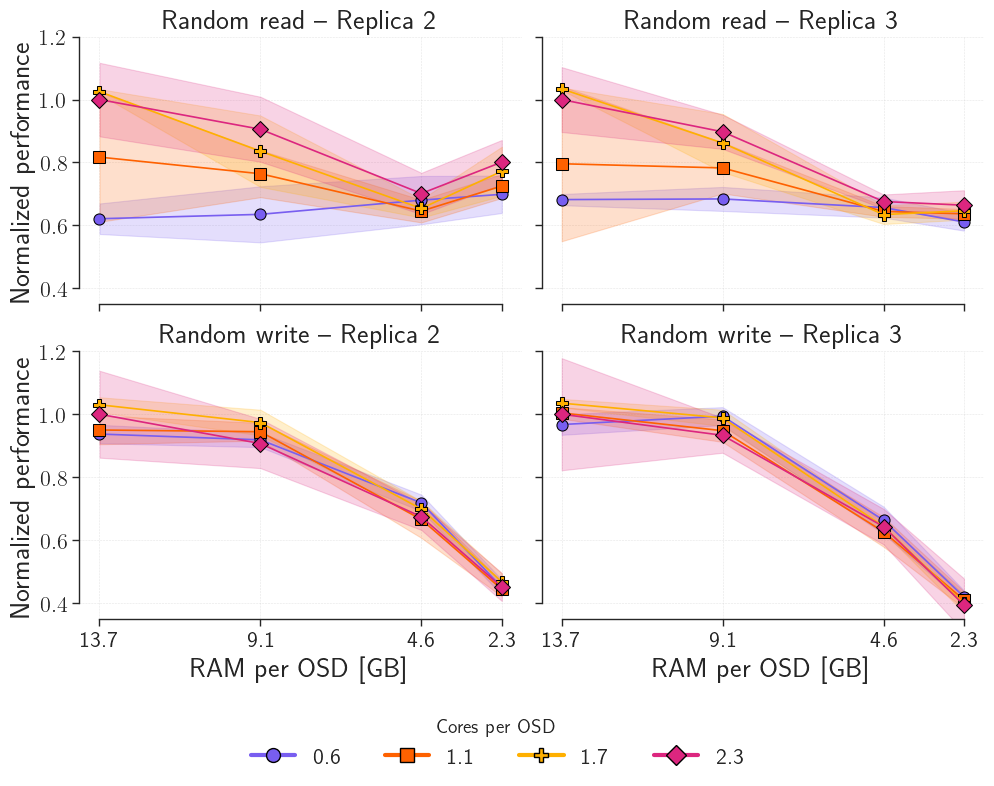

In [10]:
make_read_write_plot_aggregated(
    data=normalized_aggregated,
    randomrw=True,
    colum_to_plot="bw_norm",
    std_column = "bw_std_norm",
    savefig=True,
    filename="random.svg",
    axis_labels = ("RAM per OSD [GB]", "Normalized performance"),
    title_custom = ["Random read -- Replica 2", "Random read -- Replica 3", "Random write -- Replica 2", "Random write -- Replica 3"],
    ylim=(0.35, 1.2),
    tick_labelsize=16,
    title_fontsize=20, 
    axis_label_fontsize=20,
    legend_font_size=16,
    legend_title_font_size=14,
    legend_linewidth=3,
    legend_markersize=10,
    fig_size_override=(10, 7)
)

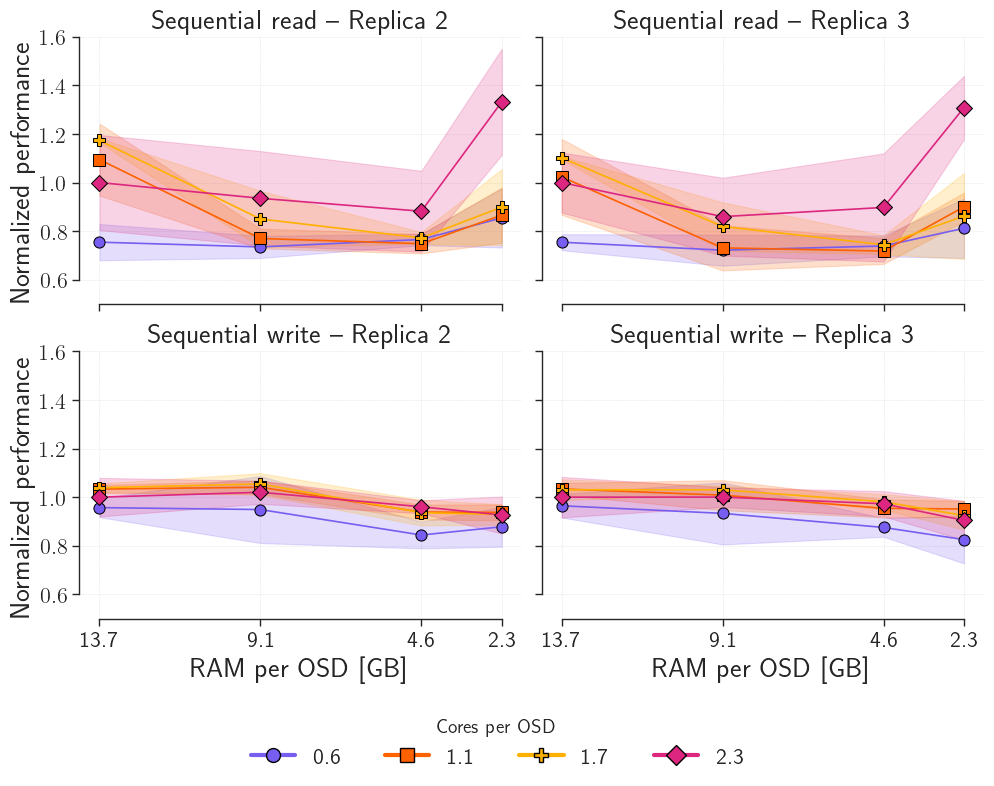

In [11]:
make_read_write_plot_aggregated(
    data=normalized_aggregated,
    randomrw=False,
    colum_to_plot="bw_norm",
    std_column = "bw_std_norm",
    savefig=True,
    filename="sequential.svg",
    axis_labels = ("RAM per OSD [GB]", "Normalized performance"),
    title_custom = ["Sequential read -- Replica 2", "Sequential read -- Replica 3", "Sequential write -- Replica 2", "Sequential write -- Replica 3"],
    ylim=(0.5, 1.6),
    tick_labelsize=16,
    title_fontsize=20, 
    axis_label_fontsize=20,
    legend_font_size=16,
    legend_title_font_size=14,
    legend_linewidth=3,
    legend_markersize=10,
    fig_size_override=(10, 7)
)

## 2nd kind of plot: 

device speed comparison

In [12]:
df = pd.DataFrame()
for core in [32]:
    for ram in [192]:
        for mode in ["read","write","randwrite","randread"]:
            for replica in [1,2,3]:
                for run_id in [1,2,3,4,5,6,7]:
                    for speed in [100,125,150,175,200,225,250,275]:
                        with open(f'multi-node/results_blkio/{mode}_replica_{replica}_core_{core}_memory_{ram}_speed_{speed}_run_{run_id}.json', 'r') as file:
                            try:
                                job = json.load(file)
                            except:
                                print(f'Error opening: results/{mode}_replica_{replica}_core_{core}_memory_{ram}_run_{run_id}.json')
                                continue
                            job=job["client_stats"]
                            #df= pd.concat([df, df_tmp], ignore_index=True)
                            if "write" in mode:
                                bw=job[5]["write"]["bw_bytes"]/1024/1024/1024
                            else:
                                bw=job[5]["read"]["bw_bytes"]/1024/1024/1024
                            bw_aggregated=0
                            for i in range(0,5):
                                if "write" in mode:
                                    bw_aggregated+=job[i]["write"]["bw_bytes"]/1024/1024/1024
                                else:
                                    bw_aggregated+=job[i]["read"]["bw_bytes"]/1024/1024/1024
                                
                            d={"core":core,"ram":ram,"mode":mode,"replica":replica,"run_id":run_id, "bw":bw,"bw_aggregated":bw_aggregated,"device_speed":speed}
                            experiment=pd.DataFrame(d, index=[0])
                            #print(experiment['jobname'])
                            df= pd.concat([df, experiment], ignore_index=True)

In [13]:
df[df["mode"] == "randread"]

,core,ram,mode,replica,run_id,bw,bw_aggregated,device_speed
504,32,192,randread,1,1,0.017953,0.018049,100
505,32,192,randread,1,1,0.017903,0.018029,125
506,32,192,randread,1,1,0.020660,0.020725,150
507,32,192,randread,1,1,0.020797,0.020906,175
508,32,192,randread,1,1,0.030195,0.030197,200
...,...,...,...,...,...,...,...,...
667,32,192,randread,3,7,0.029608,0.029628,175
668,32,192,randread,3,7,0.030889,0.030902,200
669,32,192,randread,3,7,0.030662,0.030669,225
670,32,192,randread,3,7,0.030272,0.030287,250


In [14]:
# drop the replica 1
# df = df[df["replica"] != 1]
# drop the bw_aggregated column
df = df.drop(columns=["bw_aggregated"])

agg_values = df.groupby(["mode", "core", "ram", "replica", "device_speed"]).agg(['mean', 'std']).reset_index()
agg_values.columns = ['_'.join(col).strip('_') for col in agg_values.columns.values]

# drop useless column:
agg_values = agg_values.drop(columns=['run_id_mean', 'run_id_std', "core", "ram"])
print(agg_values)

        mode  replica  device_speed   bw_mean    bw_std
0   randread        1           100  0.018396  0.000331
1   randread        1           125  0.017175  0.001482
2   randread        1           150  0.020732  0.000157
3   randread        1           175  0.028528  0.005915
4   randread        1           200  0.031558  0.001602
..       ...      ...           ...       ...       ...
91     write        3           175  2.325052  0.094155
92     write        3           200  2.343918  0.149502
93     write        3           225  2.250486  0.110448
94     write        3           250  2.354737  0.087787
95     write        3           275  2.269653  0.086181

[96 rows x 5 columns]


In [15]:
# same normalization as before, divide w.r.t. the minimum device_speed value at same mode and core
normalized_data = agg_values.copy()

# find the minimum device_speed value
normalized_data["bw_norm"] = normalized_data["bw_mean"]
normalized_data["bw_std_norm"] = normalized_data["bw_std"]

for i in range(len(normalized_data)):
    normalized_data.loc[i, "temp"] = 0 if (normalized_data["device_speed"][i] != normalized_data["device_speed"].max()) else normalized_data["bw_mean"][i]
for i in range(len(normalized_data)):
    if normalized_data["temp"][i] == 0:
        normalized_data.loc[i, "temp"] = normalized_data[(normalized_data["mode"] == normalized_data["mode"][i]) &
                                                          (normalized_data["replica"] == normalized_data["replica"][i])]["temp"].max()
for i in range(len(normalized_data)):
        normalized_data.loc[i, "bw_norm"] = normalized_data["bw_mean"][i] / normalized_data["temp"][i]
        normalized_data.loc[i, "bw_std_norm"] = normalized_data["bw_std"][i] / normalized_data["temp"][i]


normalized_data[normalized_data["mode"] == "read"].sort_values(by=["replica", "device_speed"])

,mode,replica,device_speed,bw_mean,bw_std,bw_norm,bw_std_norm,temp
48,read,1,100,1.970553,0.292736,0.985769,0.146441,1.999001
49,read,1,125,1.865276,0.571217,0.933104,0.285751,1.999001
50,read,1,150,1.927201,0.515298,0.964082,0.257778,1.999001
51,read,1,175,1.888335,0.429052,0.944639,0.214633,1.999001
52,read,1,200,1.836718,0.610925,0.918818,0.305615,1.999001
53,read,1,225,1.556516,0.453776,0.778647,0.227001,1.999001
54,read,1,250,2.099936,0.524429,1.050493,0.262346,1.999001
55,read,1,275,1.999001,0.491859,1.000000,0.246052,1.999001
56,read,2,100,2.199528,0.287173,0.967113,0.126268,2.274324
57,read,2,125,1.946552,0.605000,0.855881,0.266013,2.274324


In [16]:
def make_disk_speed_plot(
    data,
    column_to_plot="bw_mean",
    savefig: bool = True,
    filename: str = "disk_speed_plot.svg",
    palette=custom_palette,
    axis_labels=("Device Speed [MB/s]", "Bandwidth [GiB/s]"),
    axis_label_fontsize=15,
    title_custom=["Read", "Write"],
    title_fontsize=10,
    title_bold=True,
    title_fontweight='bold',  # bold, normal,
    xlim=None,
    ylim=(0, 10),
    xticks=np.array([100, 125, 150, 175, 200, 225, 250, 275]),  # Fixed: ascending order, will be inverted later
    tick_labelsize=8,
    grid_style='--',
    grid_alpha=0.5,
    grid_linewidth=0.4,
    marker_size=8,
    legend_linestyle='-',
    legend_linewidth=1.5,
    legend_markersize=6,
    legend_font_size=8,
    legend_title_font_size=8,
    legend_loc="lower center",
    legend_ncol=None,  # defaults to number of handles
    legend_bbox_to_anchor=(0.5, -0.13),
    randomrw: bool = False,
    custom_markers=['o', 's', 'P', 'D'],
    # custom_markers=['X', 'o', 's', '^'],
    show_fill: bool = True,
    std_column = "bw_std_norm",
    fill_alpha: float = 0.2,
):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    read_str = "randread" if randomrw else "read"
    write_str = "randwrite" if randomrw else "write"

    # Filter data for read and write modes
    filtered_data = data[(data["mode"].isin([read_str, write_str])) & (data["replica"] != 1)]

    # Create a mapping of replica values to custom markers
    replica_order = sorted(filtered_data["replica"].unique())
    markers_dict = {replica: custom_markers[i % len(custom_markers)] for i, replica in enumerate(replica_order)}

    # Create the plot
    ax = sns.relplot(
        data=filtered_data,
        x="device_speed",
        y=column_to_plot,
        col="mode",
        hue="replica",
        style="replica",
        markers=markers_dict,
        kind="line",
        height=3.0,
        aspect=1.3,
        dashes=False,
        palette=palette,
        markeredgecolor="black"
    )

    # Add fill areas if requested and std column exists
    if show_fill and std_column in filtered_data.columns:
        # Get the axes in the same order as the filtered data
        axes_flat = ax.axes.flat
        
        # Group data by mode to match subplot arrangement
        for i, subplot_ax in enumerate(axes_flat):
            # Determine which mode this subplot represents
            modes = sorted(filtered_data["mode"].unique())
            
            if i < len(modes):
                current_mode = modes[i]
                
                # Filter data for this specific subplot
                subplot_data = filtered_data[filtered_data["mode"] == current_mode]
                
                # Add fill areas for each replica
                for replica in replica_order:
                    replica_data = subplot_data[subplot_data["replica"] == replica].sort_values('device_speed')
                    if not replica_data.empty:
                        # Get the color for this replica from the lines
                        color = subplot_ax.lines[replica_order.index(replica)].get_color()
                        
                        # Calculate upper and lower bounds
                        upper_bound = replica_data[column_to_plot] + replica_data[std_column]
                        lower_bound = replica_data[column_to_plot] - replica_data[std_column]
                        
                        # Fill between bounds
                        subplot_ax.fill_between(
                            replica_data["device_speed"],
                            lower_bound,
                            upper_bound,
                            color=color,
                            alpha=fill_alpha,
                            interpolate=True
                        )

    ax.set_axis_labels(*axis_labels, fontsize=axis_label_fontsize)

    # Subplot titles
    for i, a in enumerate(ax.axes.flat):
        if i < len(title_custom):
            a.set_title(title_custom[i], fontsize=title_fontsize, fontweight=title_fontweight if title_bold else 'normal')

    # Ticks, grid, limits - Following working example pattern
    for a in ax.axes.flat:
        # Set x-axis limits first to ensure all data is visible
        if xlim is not None:
            a.set_xlim(xlim)
        else:
            # Add some padding to ensure all data points are visible
            data_min = filtered_data["device_speed"].min()
            data_max = filtered_data["device_speed"].max()
            padding = (data_max - data_min) * 0.05  # 5% padding
            a.set_xlim(data_min - padding, data_max + padding)  # Normal order, will be inverted
        
        # Set ticks and labels following the working example pattern
        a.set_xticks(xticks)
        a.set_xticklabels([str(int(x)) for x in xticks], fontsize=tick_labelsize)
        a.tick_params(axis='y', labelsize=tick_labelsize)
        a.set_ylim(ylim)
        a.grid(True, linestyle=grid_style, linewidth=grid_linewidth, alpha=grid_alpha)
        
        # Invert x-axis to show largest to smallest (following working example)
        a.invert_xaxis()

    # Marker size
    for ax_sub in ax.axes.flat:
        for line in ax_sub.lines:
            line.set_markersize(marker_size)

    # --- Custom legend config ---
    example_ax = ax.axes[0, 0]
    lines = example_ax.lines
    replica_to_style = {
        replica_val: (lines[i].get_color(), lines[i].get_marker())
        for i, replica_val in enumerate(replica_order)
    }

    handles = [
        Line2D(
            [0], [0],
            color=replica_to_style[replica][0],
            marker=replica_to_style[replica][1],
            markeredgecolor="black",
            linestyle=legend_linestyle,
            linewidth=legend_linewidth,
            markersize=legend_markersize,
            label=str(replica)
        )
        for replica in replica_order
    ]

    ax._legend.remove()
    ax.fig.legend(
        handles=handles,
        title="Replicas",
        loc=legend_loc,
        ncol=legend_ncol if legend_ncol else len(handles),
        frameon=False,
        bbox_to_anchor=legend_bbox_to_anchor,
        fontsize=legend_font_size,
        title_fontsize=legend_title_font_size
    )

    sns.despine(trim=True)
    plt.tight_layout()
    if savefig:
        plt.savefig(filename, format="svg", bbox_inches="tight", dpi=300)
    plt.show()

/tmp/ipykernel_5978/320731962.py:52: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.relplot(


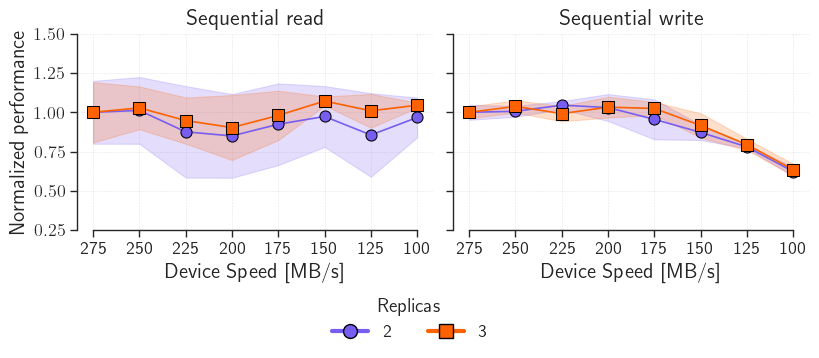

In [17]:
make_disk_speed_plot(
    data=normalized_data,  
    randomrw=False,
    savefig=True,
    filename="sequential-hdd.svg",
    ylim=(0.25,1.5),
    column_to_plot="bw_norm",
    std_column = "bw_std_norm",
    legend_font_size=13,
    legend_title_font_size=14,
    axis_label_fontsize=15,
    title_fontsize=16, 
    tick_labelsize=13,
    legend_bbox_to_anchor=(0.5, -0.2),
    axis_labels=("Device Speed [MB/s]", "Normalized performance"),
    title_custom=["Sequential read", "Sequential write"],
    legend_linewidth=3,
    legend_markersize=10
)

/tmp/ipykernel_5978/320731962.py:52: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.relplot(


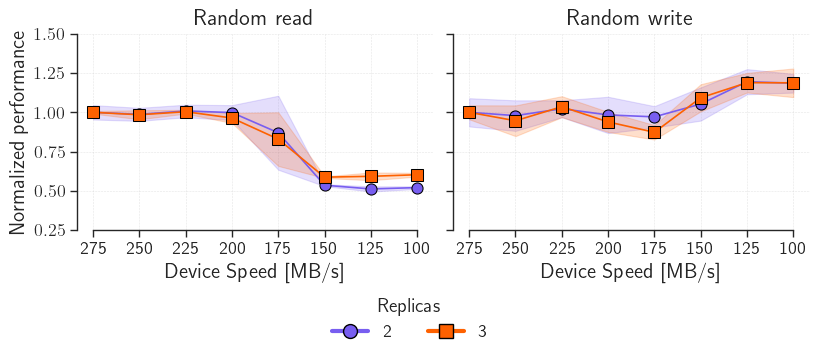

In [18]:
make_disk_speed_plot(
    data=normalized_data,
    randomrw=True,
    savefig=True,
    filename="random-hdd.svg",
     ylim=(0.25,1.5),
    column_to_plot="bw_norm",
    std_column = "bw_std_norm",
    legend_font_size=13,
    legend_title_font_size=14,
    axis_label_fontsize=15,
    title_fontsize=16, 
    tick_labelsize=13,
    legend_bbox_to_anchor=(0.5, -0.2),
    axis_labels=("Device Speed [MB/s]", "Normalized performance"),
    title_custom=["Random read", "Random write"],
    legend_linewidth=3,
    legend_markersize=10
)